<a href="https://colab.research.google.com/github/AMiNeC777/AMiNeC777/blob/main/TP1_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Dataset: Loading, Exploring, Preprocessing, and Cleaning (preserving maximum information)

In [2]:
from datasets import load_dataset

ds = load_dataset("davanstrien/WELFake")

README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

data/train-00000-of-00001-290868f0a36350(…): reconstructing file:   0%|          |  0.00B /  152MB            

data/train-00000-of-00001-290868f0a36350(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

In [3]:
ds.shape

{'train': (72134, 3)}

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'label'],
        num_rows: 72134
    })
})


In [5]:
print(ds["train"].features)

{'title': Value('string'), 'text': Value('string'), 'label': ClassLabel(names=['fake', 'real'])}


In [6]:
import pandas as pd

# Convert the training split to a DataFrame
df_train = pd.DataFrame(ds["train"])

# Preview the top 5 rows
print(df_train.head())

# Look at class distributions
print(df_train["label"].value_counts())

                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                               None   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
label
1    37106
0    35028
Name: count, dtype: int64


In [7]:
print(df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


### Checking for Duplicate Entries

In [1]:
# Check for duplicate rows based on 'title' and 'text'
duplicate_rows = df_train[df_train.duplicated(subset=['title', 'text'], keep=False)]

if not duplicate_rows.empty:
    print(f"Found {len(duplicate_rows)} duplicate rows based on 'title' and 'text'.")
    print("Examples of duplicate rows:")
    display(duplicate_rows.sort_values(by=['title', 'text']).head())
    # To preserve maximum information, we are not dropping duplicates automatically.
    # If you wish to drop them, uncomment the following lines:
    # df_train = df_train.drop_duplicates(subset=['title', 'text'], keep='first')
    # print(f"Dropped duplicate rows. New shape: {df_train.shape}")
else:
    print("No duplicate rows found based on 'title' and 'text'.")

NameError: name 'df_train' is not defined

In [8]:
df_train["has_title"] = df_train["title"].notna() & df_train["title"].str.strip().ne("")
df_train["has_text"] = df_train["text"].notna() & df_train["text"].str.strip().ne("")

df_train.groupby(["has_title", "has_text"])["label"].agg(["count","mean"])

count      mean
has_title has_text                 
False     True        558  1.000000
True      False       783  0.998723
          True      70793  0.505219

In [9]:
df_train["title"] = df_train["title"].fillna("").astype(str)
df_train["text"] = df_train["text"].fillna("").astype(str)

df_train["input"] = (
    "[TITLE] " + df_train["title"] +
    " [TEXT] " + df_train["text"]
)

In [10]:
print(df_train[["title", "text", "input", "label"]].head(3))

                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                      
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   

                                                text  \
0  No comment is expected from Barack Obama Membe...   
1     Did they post their votes for Hillary already?   
2   Now, most of the demonstrators gathered last ...   

                                               input  label  
0  [TITLE] LAW ENFORCEMENT ON HIGH ALERT Followin...      1  
1  [TITLE]  [TEXT] Did they post their votes for ...      1  
2  [TITLE] UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL...      1  


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_train["input"],
    df_train["label"],
    test_size=0.2,
    random_state=42,
    stratify=df_train["label"]
)

print(X_train.shape)
print(X_test.shape)

(57707,)
(14427,)


In [12]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
for param in model.parameters():
    param.requires_grad = False

model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [14]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [15]:
model = model.to(device)

In [16]:
def extract_features(texts, batch_size=16):

    features = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size].tolist()

        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        # Move inputs to GPU
        tokens = {k: v.to(device) for k, v in tokens.items()}

        with torch.no_grad():
            output = model(**tokens)

        # CLS embedding
        emb = output.last_hidden_state[:, 0, :]

        # Move result back to CPU
        features.append(emb.cpu())

    return torch.cat(features)

In [22]:
X_train_features = extract_features(X_train, batch_size=256)
X_test_features = extract_features(X_test, batch_size=256)

print(X_train_features.shape)
print(X_test_features.shape)

torch.Size([57707, 768])
torch.Size([14427, 768])


## 1. Baseline classique with TF-IDF and classic classification with evaluation

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for simplicity

# Fit and transform X_train
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform X_test
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (57707, 5000)
Shape of X_test_tfidf: (14427, 5000)


In [30]:
# Initialize and train a Logistic Regression model on TF-IDF features
classifier_tfidf = LogisticRegression(max_iter=1000, random_state=42)
classifier_tfidf.fit(X_train_tfidf, y_train)

print("TF-IDF Logistic Regression model trained successfully.")

TF-IDF Logistic Regression model trained successfully.


TF-IDF Model Accuracy: 0.9466

TF-IDF Model Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      7006
           1       0.94      0.95      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



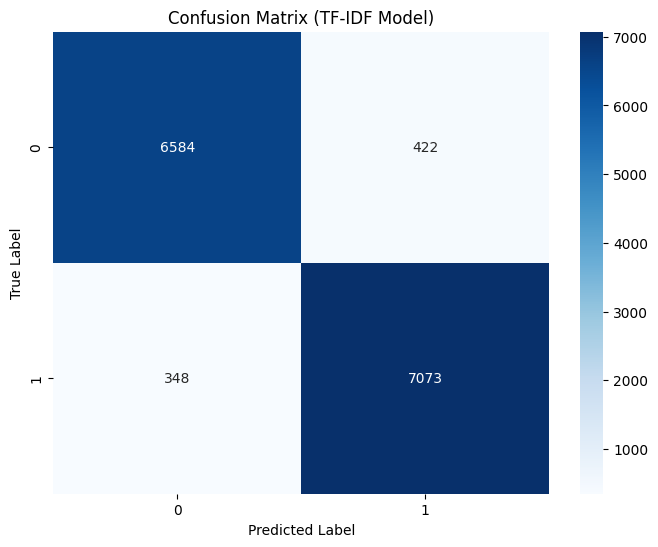

In [31]:
# Make predictions on the test set using the TF-IDF model
y_pred_tfidf = classifier_tfidf.predict(X_test_tfidf)

# Evaluate the TF-IDF model
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
report_tfidf = classification_report(y_test, y_pred_tfidf)
conf_matrix_tfidf = confusion_matrix(y_test, y_pred_tfidf)

print(f"TF-IDF Model Accuracy: {accuracy_tfidf:.4f}")
print("\nTF-IDF Model Classification Report:\n", report_tfidf)

# Plot Confusion Matrix for TF-IDF model
fig_tfidf, ax_tfidf = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix_tfidf, annot=True, fmt='d', cmap='Blues', ax=ax_tfidf)
ax_tfidf.set_xlabel('Predicted Label')
ax_tfidf.set_ylabel('True Label')
ax_tfidf.set_title('Confusion Matrix (TF-IDF Model)')
plt.show()

## 2. PLM gelé utilisé comme extracteur de features

## Model Training and Evaluation

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train_features.cpu(), y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Accuracy: 0.9491

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      7006
           1       0.95      0.95      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



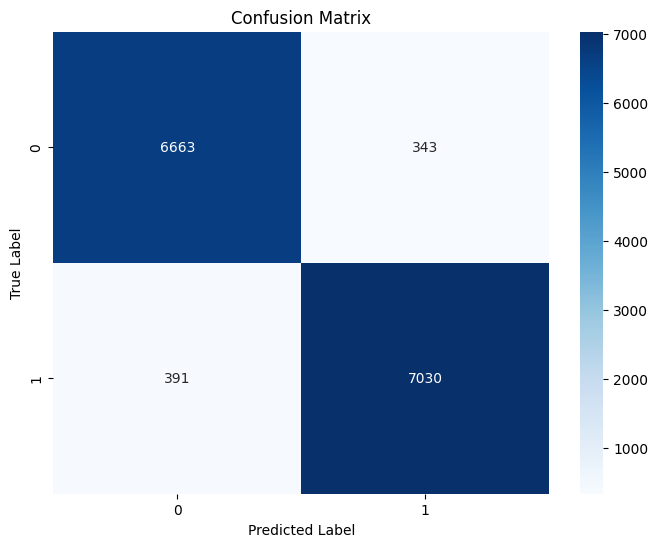

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = classifier.predict(X_test_features.cpu())

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.show()


## Analysis of Misclassified Samples

In [28]:
import numpy as np

# Convert y_test to a numpy array for easier indexing if it's not already
y_test_np = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

# Identify False Positives: True Label 0, Predicted Label 1
false_positives_indices = np.where((y_test_np == 0) & (y_pred == 1))[0]

# Identify False Negatives: True Label 1, Predicted Label 0
false_negatives_indices = np.where((y_test_np == 1) & (y_pred == 0))[0]

print(f"Number of False Positives: {len(false_positives_indices)}")
print(f"Number of False Negatives: {len(false_negatives_indices)}")

print("\n--- Examples of False Positives (True: Fake, Predicted: Real) ---")
for i, idx in enumerate(false_positives_indices[:5]): # Display first 5 false positives
    print(f"\nSample {i+1} (Index in X_test: {idx}):")
    print(f"Text: {X_test.iloc[idx]}")
    print(f"True Label: {y_test.iloc[idx]} (Fake)")
    print(f"Predicted Label: {y_pred[idx]} (Real)")

print("\n--- Examples of False Negatives (True: Real, Predicted: Fake) ---")
for i, idx in enumerate(false_negatives_indices[:5]): # Display first 5 false negatives
    print(f"\nSample {i+1} (Index in X_test: {idx}):")
    print(f"Text: {X_test.iloc[idx]}")
    print(f"True Label: {y_test.iloc[idx]} (Real)")
    print(f"Predicted Label: {y_pred[idx]} (Fake)")

Number of False Positives: 343
Number of False Negatives: 391

--- Examples of False Positives (True: Fake, Predicted: Real) ---

Sample 1 (Index in X_test: 1):
Text: [TITLE] VIDEO: Anti-Western Hindu Extremists Assault Couples in India on Valentine’s Day - Breitbart [TEXT] Lovers in India can bring a little sadism into their romance without shelling out for tickets to the Fifty Shades of Grey movies: just walk through the street holding hands, and wait for Bajrang Dal thugs to assault them. [Bajrang Dal is the youth wing of a Hindu fundamentalist organization. The party is “strictly against Western norms and believes youth should stop degrading the culture of India by celebrating Valentine’s Day,” as ANI News explains.  Bajrang Dal spends Valentine’s Day prowling the streets and pummeling any couple they chance across: #WATCH Bajrang Dal activists thrash couples in Bihar’s Muzaffarpur in a protest against Valentine’s Day pic. twitter.   —   ANI (@ANI_news) February 14, 2017,  This yea

In [26]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'Summary' # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the latest matplotlib figure object if you have one
# If you don't have a figure, remove this line or adjust accordingly.
# upload_plt_to_gcs(num_fig, step, fig)
